# AI 预测蛋白质结合位点

本 notebook 只保留 **结合位点预测** 这条技术路线，不再展开原始实现里的复杂消息传递细节。

本次教学的统一约定：
- 模型骨架统一为 `nn.Linear() + nn.ReLU()`
- 训练输出统一展示 loss history
- 结果区只保留家族主指标 `ROC AUC`和 `DCA Success Rate`，不再展示其他指标

In [23]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy.spatial import distance_matrix as scipy_dist_matrix
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

from rdkit import RDLogger

%matplotlib inline
warnings.filterwarnings("ignore")
RDLogger.DisableLog("rdApp.*")

# 定位项目根目录并设置 import 路径
_root = Path(".").resolve()
while not (_root / "demo_data").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

PROJECT_ROOT = _root
DATA_DIR = PROJECT_ROOT / "demo_data"
CORESET_FILE = DATA_DIR / "CoreSet.dat"
COMPLEX_DIR = DATA_DIR / "coreset"

from teaching_demos.common import (
    ATOM_FEAT_DIM, atom_features, build_mlp, describe_model_parameters,
    history_frame, load_complex, metric_frame, parse_pdb_ids, plot_loss_curves,
)


## 1. 超参数设置

两个最关键的超参数：

- **DISTANCE_CUTOFF = 5.0 Å**：两个蛋白原子距离小于 5 Å 就连一条边。这决定了图的稀疏程度。
- **LABEL_MIDPOINT = 5.0 Å**：蛋白原子到最近配体原子的距离小于 5 Å 时，标签接近 1（结合位点）；大于 5 Å 时，标签接近 0。

In [24]:
# ---------- 超参数 ----------
DISTANCE_CUTOFF = 5.0       # 图的边距离阈值 (Angstrom)
HIDDEN_DIM = 64             # 隐层维度
LABEL_MIDPOINT = 5.0        # 软标签 sigmoid 中点 (Angstrom)
LABEL_SLOPE = 3.0           # 软标签 sigmoid 斜率
SITE_PROB_THRESHOLD = 0.5   # 将原子判为位点原子的概率阈值
DCA_SUCCESS_CUTOFF = 4.0    # DCA 成功判定阈值 (Angstrom)
NOISE_STD = 0.02            # 训练时添加的噪声强度
N_EPOCHS = 150              # 训练轮数
LR = 5e-3                   # 学习率
BATCH_SIZE = 1              # 变长图，逐样本处理
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"计算设备: {DEVICE}")
print(f"距离阈值: {DISTANCE_CUTOFF} Å")
print(f"原子特征维度: {ATOM_FEAT_DIM}")
print(f"隐层维度: {HIDDEN_DIM}")
print(f"训练轮数: {N_EPOCHS}")


计算设备: cuda
距离阈值: 5.0 Å
原子特征维度: 10
隐层维度: 64
训练轮数: 150


## 2. 数据加载与特征提取

使用 **PDBbind CASF-2016 核心集**的子集，包含 20 个蛋白-配体复合物。

**输入文件**

| 文件 | 内容 | 用途 |
|------|------|------|
| `{pdbid}_pocket.pdb` | 蛋白质口袋的 3D 坐标 | 构建蛋白图的节点和边 |
| `{pdbid}_ligand.mol2` | 配体的 3D 坐标 | 生成训练标签（哪些原子离配体近） |

**处理流程**

1. **节点特征**：每个蛋白重原子编码为 10 维向量（8 种元素 one-hot + other + 芳香性）
2. **边**：两个蛋白原子距离 < 5 Å 就连边，边权 = 1/距离
3. **标签**：每个蛋白原子到最近配体原子的距离，通过 sigmoid 函数转为 [0, 1] 的软标签


In [ ]:
def compute_soft_labels(prot_coords, lig_coords):
    """
    生成软标签：蛋白原子离配体越近，标签越接近 1。
    label = sigmoid(-slope * (d_min - midpoint))
    """
    dist_mat = scipy_dist_matrix(prot_coords, lig_coords)
    d_min = dist_mat.min(axis=1)a
    x = -LABEL_SLOPE * (d_min - LABEL_MIDPOINT)
    labels = 1.0 / (1.0 + np.exp(-x))
    return labels.astype(np.float32)


def build_graph(coords, cutoff):
    """基于距离阈值构建空间邻近图。"""
    dist_mat = scipy_dist_matrix(coords, coords)
    src, dst = np.where((dist_mat < cutoff) & (dist_mat > 0))
    if len(src) == 0:
        nearest = np.argmin(dist_mat + np.eye(len(coords)) * 1e6, axis=1)
        src = np.arange(len(coords))
        dst = nearest
        src = np.concatenate([src, dst])
        dst = np.concatenate([nearest, np.arange(len(coords))])
    edge_index = np.stack([src, dst], axis=0).astype(np.int64)
    edge_dist = dist_mat[src, dst]
    edge_weight = (1.0 / (edge_dist + 1e-6)).reshape(-1, 1).astype(np.float32)
    return edge_index, edge_weight


def build_complex_data(pdbid):
    """构建单个蛋白-配体复合物的图数据 + 标签。"""
    cplx = load_complex(pdbid, COMPLEX_DIR)
    prot_feats = np.array([atom_features(a) for a in cplx["prot_mol"].GetAtoms()], dtype=np.float32)
    prot_coords = cplx["prot_coords"]
    lig_coords = cplx["lig_coords"]
    labels = compute_soft_labels(prot_coords, lig_coords)
    edge_index, edge_weight = build_graph(prot_coords, DISTANCE_CUTOFF)
    return prot_feats, edge_index, edge_weight, labels


In [26]:
# 展示一个样本，直观理解数据结构
pdb_ids = parse_pdb_ids(CORESET_FILE)
print(f"数据集包含 {len(pdb_ids)} 个蛋白-配体复合物\n")

sample_id = sorted(pdb_ids)[0]
feats_s, ei_s, ew_s, labels_s = build_complex_data(sample_id)

display(pd.DataFrame({
    '属性': ['PDB ID', '蛋白原子数（图的节点数）', '特征维度',
            '边数（空间近邻对）', '结合位点原子比例 (label > 0.5)'],
    '值': [sample_id, feats_s.shape[0], feats_s.shape[1],
          ei_s.shape[1], f"{(labels_s > 0.5).mean():.1%}"]
}))
print(f"\n标签分布：大部分原子远离配体（标签≈0），少数原子在结合位点附近（标签≈1）")


数据集包含 20 个蛋白-配体复合物



,属性,值
0,PDB ID,1h23
1,蛋白原子数（图的节点数）,614
2,特征维度,10
3,边数（空间近邻对）,12512
4,结合位点原子比例 (label > 0.5),23.3%



标签分布：大部分原子远离配体（标签≈0），少数原子在结合位点附近（标签≈1）


## 3. 数据集与数据加载器

将数据封装为 PyTorch Dataset。由于每个蛋白的原子数不同（变长图），逐样本处理。

In [27]:
from torch.utils.data import Dataset, DataLoader


class BindingSiteDataset(Dataset):
    """结合位点预测数据集。每个样本 = 一个蛋白图 + 逐原子软标签。"""

    def __init__(self, data_list):
        self.data = data_list

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        feats, ei, ew, labels, pdbid = self.data[idx]
        return (torch.FloatTensor(feats),
                torch.LongTensor(ei),
                torch.FloatTensor(ew),
                torch.FloatTensor(labels),
                pdbid)


# ---- 预处理所有复合物 ----
print("正在构建数据...")
all_data = []
for pdbid in sorted(pdb_ids):
    feats, ei, ew, labels = build_complex_data(pdbid)
    all_data.append((feats, ei, ew, labels, pdbid))

print(f"成功加载 {len(all_data)} 个复合物")

# ---- 80/20 划分 ----
indices = np.random.permutation(len(all_data))
split = int(0.8 * len(all_data))
train_data = [all_data[i] for i in indices[:split]]
test_data = [all_data[i] for i in indices[split:]]

train_loader = DataLoader(BindingSiteDataset(train_data), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(BindingSiteDataset(test_data), batch_size=BATCH_SIZE, shuffle=False)

display(pd.DataFrame({
    '数据集': ['训练集', '测试集', '合计'],
    '样本数': [len(train_data), len(test_data), len(all_data)],
    '比例': [f'{len(train_data)/len(all_data):.0%}',
            f'{len(test_data)/len(all_data):.0%}', '100%']
}))


正在构建数据...
成功加载 20 个复合物


,数据集,样本数,比例
0,训练集,16,80%
1,测试集,4,20%
2,合计,20,100%


## 4. 模型架构

```
原子特征 (N, 10)
    │
    ▼  编码器：线性变换到隐空间
隐层表示 (N, 64)
    │
    ▼  消息传递：每个原子聚合周围原子的信息（加权平均）
更新后表示 (N, 64)
    │
    ▼  分类头：每个原子输出「是否为结合位点」的概率
预测 (N, 1)
```

消息传递是核心：一个原子本身的特征（元素类型、芳香性）不足以判断它是否是结合位点，
但如果它知道周围 5 Å 内都有哪些原子、形成了怎样的空间排布，判断就容易得多。
这正是 GNN 消息传递的作用——让每个原子「看到」周围的结构环境。


In [28]:
def build_neighbor_context(node_h, edge_index, edge_weight):
    num_nodes = node_h.size(0)
    neigh_h = torch.zeros_like(node_h)
    density = torch.zeros(num_nodes, 1, device=node_h.device)

    if edge_index.numel() == 0:
        return neigh_h, density

    src, dst = edge_index
    weights = edge_weight.reshape(-1, 1).to(node_h.device)
    neigh_h.index_add_(0, dst, node_h[src] * weights)
    density.index_add_(0, dst, weights)
    neigh_h = neigh_h / density.clamp_min(1e-6)
    density = density / density.max().clamp_min(1.0)
    return neigh_h, density


In [29]:
class GrASPToyModel(nn.Module):
    """用最简单的 MLP 骨架做逐原子位点打分。"""

    def __init__(self, in_dim=ATOM_FEAT_DIM, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.node_encoder = build_mlp(in_dim, hidden_dim, hidden_dim)
        self.classifier = build_mlp(hidden_dim * 3 + 1, hidden_dim, 1)

    def forward(self, feats, edge_index, edge_weight):
        node_h = self.node_encoder(feats)
        global_h = node_h.mean(dim=0, keepdim=True).expand_as(node_h)
        neigh_h, density = build_neighbor_context(node_h, edge_index, edge_weight)
        logits = self.classifier(torch.cat([node_h, global_h, neigh_h, density], dim=-1))
        return logits.squeeze(-1)


model = GrASPToyModel().to(DEVICE)
display(describe_model_parameters(model))

,层名称,形状,参数量
0,node_encoder.0.weight,"(64, 10)",640
1,node_encoder.0.bias,"(64,)",64
2,node_encoder.2.weight,"(64, 64)",4096
3,node_encoder.2.bias,"(64,)",64
4,classifier.0.weight,"(64, 193)",12352
5,classifier.0.bias,"(64,)",64
6,classifier.2.weight,"(1, 64)",64
7,classifier.2.bias,"(1,)",1
8,总计,-,17345


## 5. 训练

训练目标：让模型学会从蛋白图结构中判断每个原子是否是结合位点。

两个训练技巧：
- **Noisy Nodes**：训练时对输入特征加少量噪声，防止过拟合
- **多任务损失**：分类损失 + 重建损失，后者要求模型保留原始特征信息

In [30]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.BCEWithLogitsLoss()

train_loss_history = []
val_loss_history = []

print(f"开始训练 {N_EPOCHS} 轮...\n")

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    batch_losses = []

    for feats, ei, ew, labels, _pdbid in train_loader:
        feats = feats.squeeze(0).to(DEVICE)
        ei = ei.squeeze(0).to(DEVICE)
        ew = ew.squeeze(0).to(DEVICE)
        labels = labels.squeeze(0).to(DEVICE)

        noisy_feats = feats + NOISE_STD * torch.randn_like(feats)
        logits = model(noisy_feats, ei, ew)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    train_loss = float(np.mean(batch_losses)) if batch_losses else float("nan")
    train_loss_history.append(train_loss)

    model.eval()
    val_losses = []
    all_probs, all_labels = [], []
    with torch.no_grad():
        for feats, ei, ew, labels, _pdbid in test_loader:
            feats = feats.squeeze(0).to(DEVICE)
            ei = ei.squeeze(0).to(DEVICE)
            ew = ew.squeeze(0).to(DEVICE)
            labels = labels.squeeze(0).to(DEVICE)
            logits = model(feats, ei, ew)
            val_losses.append(criterion(logits, labels).item())
            all_probs.append(torch.sigmoid(logits).cpu().numpy())
            all_labels.append((labels > 0.5).cpu().numpy().astype(int))

    val_loss = float(np.mean(val_losses)) if val_losses else float("nan")
    val_loss_history.append(val_loss)

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    val_auc = roc_auc_score(all_labels, all_probs) if len(np.unique(all_labels)) > 1 else float("nan")

    if epoch == 1 or epoch % 20 == 0:
        print(
            f"Epoch {epoch:>3d}/{N_EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | ROC AUC: {val_auc:.4f}"
        )

history_df = history_frame(train_loss_history, val_loss_history)


开始训练 150 轮...

Epoch   1/150 | Train Loss: 0.5587 | Val Loss: 0.5017 | ROC AUC: 0.5131
Epoch  20/150 | Train Loss: 0.4795 | Val Loss: 0.4692 | ROC AUC: 0.6591
Epoch  40/150 | Train Loss: 0.4633 | Val Loss: 0.4467 | ROC AUC: 0.7304
Epoch  60/150 | Train Loss: 0.4537 | Val Loss: 0.4393 | ROC AUC: 0.7450
Epoch  80/150 | Train Loss: 0.4507 | Val Loss: 0.4422 | ROC AUC: 0.7376
Epoch 100/150 | Train Loss: 0.4453 | Val Loss: 0.4438 | ROC AUC: 0.7361
Epoch 120/150 | Train Loss: 0.4415 | Val Loss: 0.4450 | ROC AUC: 0.7375
Epoch 140/150 | Train Loss: 0.4425 | Val Loss: 0.4383 | ROC AUC: 0.7481


## 6. 统一评估与可视化

- 统一展示训练的 loss history。
- 保留逐原子分类指标 `ROC AUC`，并补充口袋中心层面的 `DCA Success Rate (<= 4 Å)`。


In [31]:
def find_site_components(edge_index, active_mask):
    active_nodes = np.flatnonzero(active_mask)
    if active_nodes.size == 0:
        return []

    adjacency = {int(node): [] for node in active_nodes}
    src, dst = edge_index
    for s, d in zip(src.tolist(), dst.tolist()):
        if active_mask[s] and active_mask[d]:
            adjacency[int(s)].append(int(d))
            adjacency[int(d)].append(int(s))

    components = []
    visited = set()
    for node in active_nodes.tolist():
        if node in visited:
            continue
        stack = [int(node)]
        visited.add(int(node))
        component = []
        while stack:
            current = stack.pop()
            component.append(current)
            for neighbor in adjacency[current]:
                if neighbor not in visited:
                    visited.add(neighbor)
                    stack.append(neighbor)
        components.append(np.array(sorted(component), dtype=np.int64))
    return components


def probability_weighted_center(coords, probs):
    weights = np.clip(probs, 1e-6, None).astype(np.float32)
    weights = weights / weights.sum()
    return np.sum(coords * weights[:, None], axis=0)


def dca_distance(center, lig_coords):
    return float(np.linalg.norm(lig_coords - center, axis=1).min())


def predict_site_centers(prot_coords, edge_index, probs, threshold=SITE_PROB_THRESHOLD):
    active_mask = probs >= threshold
    components = find_site_components(edge_index, active_mask)
    centers = []
    for component in components:
        centers.append(probability_weighted_center(prot_coords[component], probs[component]))
    return centers


model.eval()
all_probs, all_labels = [], []
predicted_site_total = 0
successful_site_total = 0
no_prediction_complexes = 0
dca_rows = []

with torch.no_grad():
    for feats, ei, ew, labels, pdbid in test_loader:
        pdbid = pdbid[0]
        feats = feats.squeeze(0).to(DEVICE)
        edge_index = ei.squeeze(0)
        edge_index_np = edge_index.cpu().numpy()
        ei = edge_index.to(DEVICE)
        ew = ew.squeeze(0).to(DEVICE)
        label_array = labels.squeeze(0).cpu().numpy()

        logits = model(feats, ei, ew)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.append(probs)
        all_labels.append((label_array > 0.5).astype(int))

        cplx = load_complex(pdbid, COMPLEX_DIR)
        prot_coords = cplx["prot_coords"]
        lig_coords = cplx["lig_coords"]
        site_centers = predict_site_centers(prot_coords, edge_index_np, probs)
        dca_values = [dca_distance(center, lig_coords) for center in site_centers]

        if not dca_values:
            no_prediction_complexes += 1

        success_count = int(np.sum(np.array(dca_values) <= DCA_SUCCESS_CUTOFF)) if dca_values else 0
        predicted_site_total += len(dca_values)
        successful_site_total += success_count
        best_dca = min(dca_values) if dca_values else float("nan")

        dca_rows.append({
            "PDB ID": pdbid,
            "预测位点数": len(dca_values),
            f"成功位点数 (DCA <= {DCA_SUCCESS_CUTOFF:.0f}Å)": success_count,
            "最佳 DCA (Å)": round(best_dca, 3) if np.isfinite(best_dca) else np.nan,
        })

all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)
global_auc = roc_auc_score(all_labels, all_probs) if len(np.unique(all_labels)) > 1 else float("nan")
dca_success_rate = successful_site_total / predicted_site_total if predicted_site_total else float("nan")

results_df = metric_frame([
    ("ROC AUC", f"{global_auc:.4f}"),
    (f"DCA Success Rate (<= {DCA_SUCCESS_CUTOFF:.0f} Å)", f"{dca_success_rate:.4f}"),
    ("Predicted Sites", predicted_site_total),
    ("Successful Sites", successful_site_total),
    ("No-prediction Complexes", no_prediction_complexes),
])
display(results_df)


,指标,值
0,ROC AUC,0.7497
1,DCA Success Rate (<= 4 Å),0.2857
2,Predicted Sites,7
3,Successful Sites,2
4,No-prediction Complexes,0


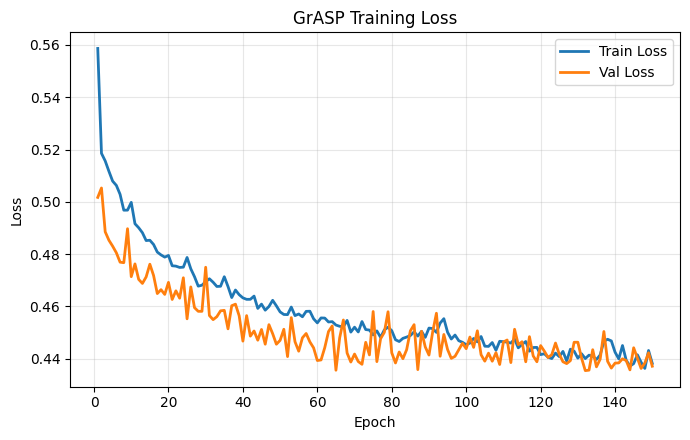

In [32]:
plot_loss_curves(train_loss_history, val_loss_history, title="GrASP Training Loss")

## 总结

- 技术路线：对蛋白原子做逐点位点打分，并把高分原子聚成预测位点中心。
- 教学骨架：统一为 `nn.Linear() + nn.ReLU()` 的简单 MLP。
- 训练输出：统一展示 train / val loss history。
- 评估同时展示 `ROC AUC` 和 `DCA Success Rate (<= 4 Å)`。
